In [1]:
import json, sys, os
import numpy as np
import pandas as pd
from enum import Enum
from scipy.optimize import root_scalar
from typing import Dict, Tuple, Union, Optional
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid")
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
print("Added to sys.path:", repo_root)
from fixedincomelib import *
print("Fixed Income Library is loaded.")

Added to sys.path: /Users/tiffanyyan/Documents/GitHub/QuantBricker
Fixed Income Library is loaded.


### Test Alpha Parameterization

In [2]:
### parameters
alpha = 0.04
beta = 0.6
nu = 0.5
rho = 0.5
shift = 0.04
forward = 0.04
strike = 0.042
tte = 0.5
opt_type = 'call'

In [3]:
### alpha parameterization
value_and_sensitivitities_alpha = qfEuropeanOptionSABR(
    forward,
    strike,
    tte,
    opt_type,
    alpha,
    beta,
    rho,
    nu,
    shift, 
    True)
value_and_sensitivitities_alpha

{<SimpleMetrics.PV: 'pv'>: 0.0017144892995766443,
 <SimpleMetrics.DELTA: 'delta'>: 0.35135502903790594,
 <SimpleMetrics.GAMMA: 'gamma'>: 57.150173482511946,
 <SimpleMetrics.THETA: 'theta'>: -0.0025135840296122776,
 <SimpleMetrics.TTE_RISK: 'tte_risk'>: 0.002471438222218009,
 <SimpleMetrics.STRIKE_RISK: 'strike_risk'>: -0.33360000029012304,
 <SabrMetrics.DALPHA: 'dalpha'>: 0.0600804375208899,
 <SabrMetrics.DBETA: 'dbeta'>: -0.006032271544292513,
 <SabrMetrics.DRHO: 'drho'>: 9.966404659412754e-05,
 <SabrMetrics.DNU: 'dnu'>: 0.00022073305755336385,
 <SimpleMetrics.STRIKE_RISK_2: 'strike_risk_2'>: 55.4836697419514}

In [4]:
### b&r test -- first order
from scipy.differentiate import derivative


key = SimpleMetrics.PV
base_v = value_and_sensitivitities_alpha[key]
epsilon = 1e-6
bump_vec = [0.0] * 7
for i in range(len(bump_vec)):
    bump_vec[i] += epsilon
    bumped_v = qfEuropeanOptionSABR(
        forward + bump_vec[0],
        strike + bump_vec[1],
        tte - bump_vec[2],
        opt_type,
        alpha + bump_vec[3],
        beta + bump_vec[4],
        rho + bump_vec[5],
        nu + bump_vec[6],
        shift,
    )
    derivative_name = [SabrMetrics.D_LN_SIGMA_D_FORWARD, SabrMetrics.D_LN_SIGMA_D_STRIKE, SabrMetrics.D_LN_SIGMA_D_TTE,
                       SabrMetrics.D_LN_SIGMA_D_ALPHA, SabrMetrics.D_LN_SIGMA_D_BETA, SabrMetrics.D_LN_SIGMA_D_RHO, SabrMetrics.D_LN_SIGMA_D_NU][i]
    print(f"{derivative_name} is {(bumped_v[key] - base_v) / epsilon}.")
    # display((bumped_v[key] - base_v) / epsilon)
    bump_vec[i] -= epsilon
    
# second order
bumped_up = qfEuropeanOptionSABR(
    forward + epsilon, strike, tte, opt_type, alpha, beta, rho, nu, shift
)[SimpleMetrics.PV]
bumped_dn = qfEuropeanOptionSABR(
    forward - epsilon, strike, tte, opt_type, alpha, beta, rho, nu, shift
)[SimpleMetrics.PV]
print(f"Gamma is {(bumped_up - 2 * base_v + bumped_dn)/epsilon/epsilon}.")
bumped_up = qfEuropeanOptionSABR(
    forward, strike + epsilon, tte, opt_type, alpha, beta, rho, nu, shift
)[SimpleMetrics.PV]
bumped_dn = qfEuropeanOptionSABR(
    forward, strike - epsilon, tte, opt_type, alpha, beta, rho, nu, shift
)[SimpleMetrics.PV]
print(f"Second Order Strike Risk is {(bumped_up - 2 * base_v + bumped_dn)/epsilon/epsilon}.")

SabrMetrics.D_LN_SIGMA_D_FORWARD is 0.35138360492820153.
SabrMetrics.D_LN_SIGMA_D_STRIKE is -0.3335722594255408.
SabrMetrics.D_LN_SIGMA_D_TTE is -0.002513585110885952.
SabrMetrics.D_LN_SIGMA_D_ALPHA is 0.06008051023354.
SabrMetrics.D_LN_SIGMA_D_BETA is -0.006032263265287607.
SabrMetrics.D_LN_SIGMA_D_RHO is 9.966398886729344e-05.
SabrMetrics.D_LN_SIGMA_D_NU is 0.00022073313316051113.
Gamma is 57.150173482511946.
Second Order Strike Risk is 55.4836697419514.


### Test Log-Normal Parameterization

In [5]:
### parameters
ln_sigma_atm = 0.1108019639023036
beta = 0.6
nu = 0.5
rho = 0.5
shift = 0.04
forward = 0.04
strike = 0.042
tte = 0.5
opt_type = 'call'

In [6]:
### ln_sigma parameterization
value_and_sensitivitities_ln_sigma = qfEuropeanOptionSABR(
    forward,
    strike,
    tte,
    opt_type,
    ln_sigma_atm,
    beta,
    rho,
    nu,
    shift, 
    True,
    False)
value_and_sensitivitities_ln_sigma

{<SimpleMetrics.PV: 'pv'>: 0.0017144892995766443,
 <SimpleMetrics.DELTA: 'delta'>: 0.3633711165420839,
 <SimpleMetrics.GAMMA: 'gamma'>: 58.2925305248061,
 <SimpleMetrics.THETA: 'theta'>: -0.0024726386741724606,
 <SimpleMetrics.TTE_RISK: 'tte_risk'>: 0.002471438222218009,
 <SimpleMetrics.STRIKE_RISK: 'strike_risk'>: -0.33360000029012304,
 <SabrMetrics.DBETA: 'dbeta'>: 2.99194787451015e-05,
 <SabrMetrics.DRHO: 'drho'>: 0.00012701992542436542,
 <SabrMetrics.DNU: 'dnu'>: 0.00014901993518101652,
 <SimpleMetrics.STRIKE_RISK_2: 'strike_risk_2'>: 55.4836697419514,
 <SabrMetrics.DLNSIGMA: 'dlnsigma'>: 0.021643377266276912}

In [7]:
### b&r test -- first order
key = SimpleMetrics.PV
base_v = value_and_sensitivitities_ln_sigma[key]
epsilon = 1e-6
bump_vec = [0.] * 7
for i in range(len(bump_vec)):
    bump_vec[i] += epsilon    
    bumped_v = qfEuropeanOptionSABR(
        forward + bump_vec[0],
        strike + bump_vec[1],
        tte + bump_vec[2],
        opt_type,
        ln_sigma_atm + bump_vec[3],
        beta + bump_vec[4],
        rho + bump_vec[5],
        nu + bump_vec[6],
        shift,
        is_alpha_parameterized=False)
    # display((bumped_v[key] - base_v) / epsilon)
    derivative_name = [SabrMetrics.D_LN_SIGMA_D_FORWARD, SabrMetrics.D_LN_SIGMA_D_STRIKE, SabrMetrics.D_LN_SIGMA_D_TTE,
                       SabrMetrics.DLNSIGMA, SabrMetrics.D_LN_SIGMA_D_BETA, SabrMetrics.D_LN_SIGMA_D_RHO, SabrMetrics.D_LN_SIGMA_D_NU][i]
    print(f"{derivative_name} is {(bumped_v[key] - base_v) / epsilon}.")
    bump_vec[i] -= epsilon
# second order
bumped_up = qfEuropeanOptionSABR(forward + epsilon, strike, tte, opt_type, ln_sigma_atm, beta, rho, nu, shift, is_alpha_parameterized=False)[SimpleMetrics.PV]
bumped_dn = qfEuropeanOptionSABR(forward - epsilon, strike, tte, opt_type, ln_sigma_atm, beta, rho, nu, shift, is_alpha_parameterized=False)[SimpleMetrics.PV]
print(f'Gamma is {(bumped_up - 2 * base_v + bumped_dn)/epsilon/epsilon}.')
bumped_up = qfEuropeanOptionSABR(forward, strike + epsilon, tte, opt_type, ln_sigma_atm, beta, rho, nu, shift, is_alpha_parameterized=False)[SimpleMetrics.PV]
bumped_dn = qfEuropeanOptionSABR(forward, strike - epsilon, tte, opt_type, ln_sigma_atm, beta, rho, nu, shift, is_alpha_parameterized=False)[SimpleMetrics.PV]
print(f'Second Order Strike Risk is {(bumped_up - 2 * base_v + bumped_dn)/epsilon/epsilon}.')


SabrMetrics.D_LN_SIGMA_D_FORWARD is 0.3634002634887723.
SabrMetrics.D_LN_SIGMA_D_STRIKE is -0.3335722594255408.
SabrMetrics.D_LN_SIGMA_D_TTE is 0.0024726375426331604.
SabrMetrics.DLNSIGMA is 0.021643386288044963.
SabrMetrics.D_LN_SIGMA_D_BETA is 2.9919469679562383e-05.
SabrMetrics.D_LN_SIGMA_D_RHO is 0.000127019905010739.
SabrMetrics.D_LN_SIGMA_D_NU is 0.00014901994915827999.
Gamma is 58.2925305248061.
Second Order Strike Risk is 55.4836697419514.


### Test Normal Sigma Parameterization

In [8]:
# parameters
sigma_nv = 0.008
beta = 0.6
nu = 0.5
rho = 0.5
shift = 0.04
forward = 0.04
strike = 0.042
tte = 0.5
opt_type = 'call'

In [9]:
### normal sigma parameterization
value_and_sensitivitities_normal_sigma = qfEuropeanOptionSABRNormal(
    forward,
    strike,
    tte,
    opt_type,
    sigma_nv,
    beta,
    rho,
    nu,
    shift, 
    True)
value_and_sensitivitities_normal_sigma

{<SimpleMetrics.PV: 'pv'>: 0.001482305015118264,
 <SimpleMetrics.DELTA: 'delta'>: 0.322326821354036,
 <SimpleMetrics.GAMMA: 'gamma'>: 60.37938898861839,
 <SimpleMetrics.THETA: 'theta'>: -0.0022173987622294755,
 <SimpleMetrics.TTE_RISK: 'tte_risk'>: 0.0022153289796701878,
 <SimpleMetrics.STRIKE_RISK: 'strike_risk'>: -0.32252420914536306,
 <SabrMetrics.DBETA: 'dbeta'>: 2.672721099023466e-05,
 <SabrMetrics.DRHO: 'drho'>: 0.000124864732460657,
 <SabrMetrics.DNU: 'dnu'>: 0.00014850861091232322,
 <SimpleMetrics.STRIKE_RISK_2: 'strike_risk_2'>: 60.20168044629237,
 <SabrMetrics.DNORMALSIGMA: 'dnormalsigma'>: 0.2678930570966642}

In [10]:
### b&r test -- first order
key = SimpleMetrics.PV
base_v = value_and_sensitivitities_normal_sigma[key]
epsilon = 1e-6
bump_vec = [0.] * 7
for i in range(len(bump_vec)):
    bump_vec[i] += epsilon    
    bumped_v = qfEuropeanOptionSABRNormal(
        forward + bump_vec[0],
        strike + bump_vec[1],
        tte - bump_vec[2],
        opt_type,
        sigma_nv + bump_vec[3],
        beta + bump_vec[4],
        rho + bump_vec[5],
        nu + bump_vec[6],
        shift)
    display((bumped_v[key] - base_v) / epsilon)
    bump_vec[i] -= epsilon
# second order
bumped_up = qfEuropeanOptionSABRNormal(forward + epsilon, strike, tte, opt_type, sigma_nv, beta, rho, nu, shift)[SimpleMetrics.PV]
bumped_dn = qfEuropeanOptionSABRNormal(forward - epsilon, strike, tte, opt_type, sigma_nv, beta, rho, nu, shift)[SimpleMetrics.PV]
print(f'Gamma is {(bumped_up - 2 * base_v + bumped_dn)/epsilon/epsilon}.')
bumped_up = qfEuropeanOptionSABRNormal(forward, strike + epsilon, tte, opt_type, sigma_nv, beta, rho, nu, shift)[SimpleMetrics.PV]
bumped_dn = qfEuropeanOptionSABRNormal(forward, strike - epsilon, tte, opt_type, sigma_nv, beta, rho, nu, shift)[SimpleMetrics.PV]
print(f'Second Order Strike Risk is {(bumped_up - 2 * base_v + bumped_dn)/epsilon/epsilon}.')


0.3223570122674879

-0.3224941095142375

-0.0022173997325791728

0.26789496675172497

2.67272072529412e-05

0.0001248647296669958

0.00014850863594428887

Gamma is 60.37938898861839.
Second Order Strike Risk is 60.20168044629237.


In [11]:
### b&r test -- first order
key = SimpleMetrics.PV
base_v = value_and_sensitivitities_normal_sigma[key]
epsilon = 1e-6 
bumped_up = qfEuropeanOptionSABRNormal(
    forward,
    strike,
    tte,
    opt_type,
    sigma_nv,
    beta + epsilon/2.,
    rho,
    nu,
    shift)
bumped_dn = qfEuropeanOptionSABRNormal(
    forward,
    strike,
    tte,
    opt_type,
    sigma_nv,
    beta - epsilon/2.,
    rho,
    nu,
    shift)
(bumped_up[SimpleMetrics.PV] - bumped_dn[SimpleMetrics.PV])/epsilon

2.6727221130729006e-05

### Test SABR CDF and PDF

In [12]:
# parameters
sigma_nv = 0.008
beta = 0.6
nu = 0.5
rho = 0.5
shift = 0.04
forward = 0.04
tte = 0.5

# grid spec
x_min = - shift + 1e-4
x_max = 0.1
num_pts = 1000

### sapmling
df_res = qfEuropeanOptionSABRPdfAndCdf(
    forward,
    tte,
    sigma_nv,
    beta,
    rho,
    nu,
    x_min,
    x_max,
    num_pts,
    shift,
    False,
    False)

In [13]:
from fixedincomelib.analytics.sabr import SABRAnalytics, SabrMetrics
from fixedincomelib.analytics.european_options import EuropeanOptionAnalytics, SimpleMetrics, CallOrPut


alpha_res = SABRAnalytics.alpha_from_atm_normal_sigma(
    forward, tte, sigma_nv, beta, rho, nu, shift
)
alpha = alpha_res[SabrMetrics.ALPHA]

def call_price(k):
    ln_res = SABRAnalytics.lognormal_vol_from_alpha(
        forward, k, tte, alpha, beta, rho, nu, shift
    )
    sigma = ln_res[SimpleMetrics.IMPLIED_LOG_NORMAL_VOL]
    res = EuropeanOptionAnalytics.european_option_log_normal(
        forward + shift, k + shift, tte, sigma, CallOrPut.CALL
    )
    return res[SimpleMetrics.PV]

eps = 1e-5
ks = df_res['Forward'].values
cdf_analytic = df_res['Cdf'].values
pdf_analytic = df_res['Pdf'].values

cdf_numerical, pdf_numerical = [], []
for k in ks:
    c0 = call_price(k)
    cp = call_price(k + eps)
    cm = call_price(k - eps)
    cdf_numerical.append(1 + (cp - cm) / (2 * eps))     
    pdf_numerical.append((cp - 2*c0 + cm) / eps**2)     


cdf_err = np.abs(np.array(cdf_numerical) - cdf_analytic)
pdf_err = np.abs(np.array(pdf_numerical) - pdf_analytic)
print(f"CDF max error: {cdf_err.max():.2e}")  
print(f"PDF max error: {pdf_err.max():.2e}") 

CDF max error: 1.80e-07
PDF max error: 2.76e-05


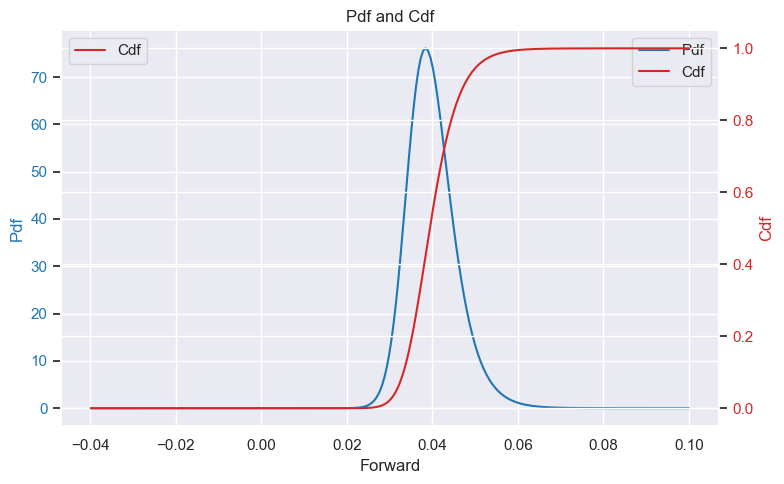

In [14]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# PDF on left y-axis
sns.lineplot(data=df_res, x="Forward", y="Pdf", ax=ax1, color="tab:blue", label="Pdf")
ax1.set_ylabel("Pdf", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
# CDF on right y-axis
ax2 = ax1.twinx()
sns.lineplot(data=df_res, x="Forward", y="Cdf", ax=ax2, color="tab:red", label="Cdf")
ax2.set_ylabel("Cdf", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
# Shared x-axis label
ax1.set_xlabel("Forward")
# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
plt.title("Pdf and Cdf")
plt.tight_layout()
plt.show()

In [15]:
# lower wing parameters
alpha = 0.05
beta = 0.5
nu = 0.68
rho = 0.61
shift = 0.0
forward = 0.55/100
tte = 1

# grid spec
x_min = -shift + 1e-4
x_max = 0.1
num_pts = 1000

df_res = qfEuropeanOptionSABRPdfAndCdf(
    forward,
    tte,
    alpha,
    beta,
    rho,
    nu,
    x_min,
    x_max,
    num_pts,
    shift,
    True,
    False,
)


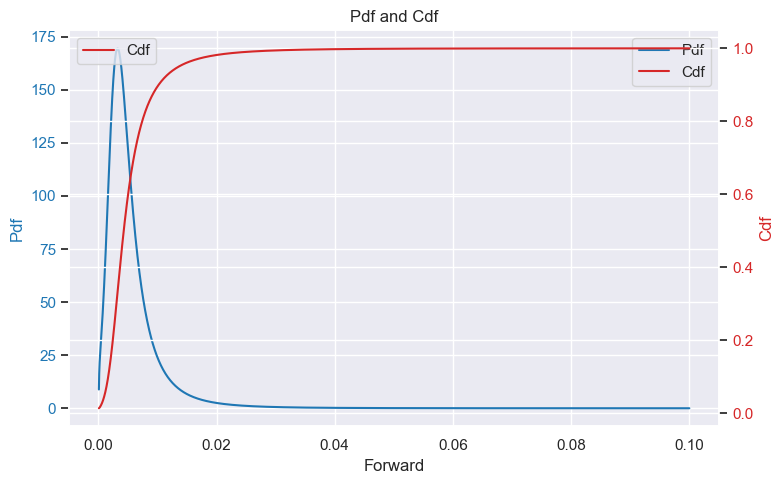

In [16]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# PDF on left y-axis
sns.lineplot(data=df_res, x="Forward", y="Pdf", ax=ax1, color="tab:blue", label="Pdf")
ax1.set_ylabel("Pdf", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
# CDF on right y-axis
ax2 = ax1.twinx()
sns.lineplot(data=df_res, x="Forward", y="Cdf", ax=ax2, color="tab:red", label="Cdf")
ax2.set_ylabel("Cdf", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
# Shared x-axis label
ax1.set_xlabel("Forward")
# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
plt.title("Pdf and Cdf")
plt.tight_layout()
plt.show()

In [17]:
# lower wing parameters
alpha = 0.0512
beta = 0.5
nu = 0.322
rho = -9.5/100
shift = 0.0
forward = 3.54/100
tte = 10

# grid spec
x_min = -shift + 1e-4
x_max = 0.1
num_pts = 1000

df_res = qfEuropeanOptionSABRPdfAndCdf(
    forward,
    tte,
    alpha,
    beta,
    rho,
    nu,
    x_min,
    x_max,
    num_pts,
    shift,
    True,
    False,
)


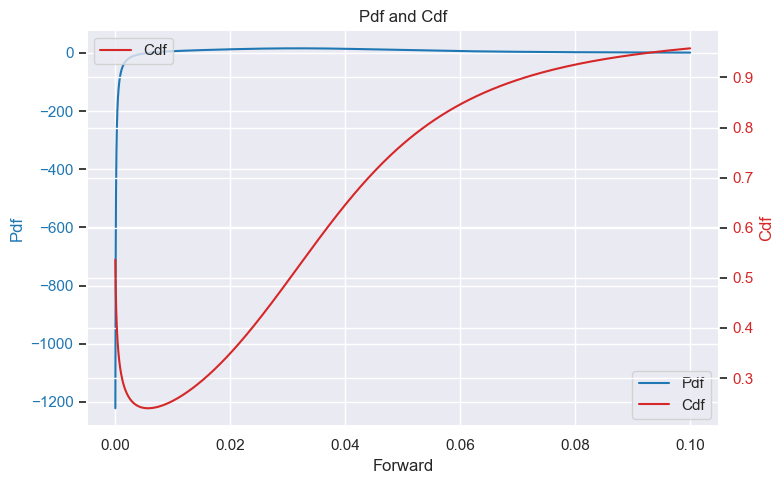

In [18]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# PDF on left y-axis
sns.lineplot(data=df_res, x="Forward", y="Pdf", ax=ax1, color="tab:blue", label="Pdf")
ax1.set_ylabel("Pdf", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
# CDF on right y-axis
ax2 = ax1.twinx()
sns.lineplot(data=df_res, x="Forward", y="Cdf", ax=ax2, color="tab:red", label="Cdf")
ax2.set_ylabel("Cdf", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
# Shared x-axis label
ax1.set_xlabel("Forward")
# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
plt.title("Pdf and Cdf")
plt.tight_layout()
plt.show()